**Project Scope:**
1. Dataset

    - Methodology: Evaluated three candidate datasets (RuleArena, HiDF, EmoryNLP).

    - Findings: Selected the HiDF dataset (specifically the image subset) because deepfake detection is a highly relevant problem, the large dataset is well-organized (allowing for a greater focus on datamining techniques), and the high-dimensional nature of the problem adds unique challenges (likely requiring comression).

2. Metadata Analysis

    - Methodology: Downloaded and extracted the HiDF images and metadata, then plotted distributions of the metadata (Race, Gender, Age, and Base/Swap image frequencies).

    - Findings: Base image usage is uniform (average usage ~1). Swap image usage is slightly less uniform but not severely problematic. However, the metadata features (Race, Gender, Age) are highly skewed (e.g., disproportionately featuring white adults), likely due to biases in the source datasets (CelebA-HQ, Flickr). The model might overfit to this plurality groups if not appropriately handled.

3. Gradient/Pixel Intensity Analysis

    - Methodology: Analyzed global pixel values (intensity, standard deviation, skew, kurtosis) and average gradients across the Real and Fake datasets.

    - Findings: Intensity values between Real and Fake images are nearly identical. However, there is a significant disparity in gradients from real to fake images. This likely indicates "smoothing" artifacts from the deepfake "stitching" process. Because some backgrounds can be more busy than others, simple global thresholding porbably won't work.

4. Dimension Reduction (PCA)

    - Methodology: Applied Principal Component Analysis (PCA) across different input resolutions to determine the optimal compression of the high-dimensional image data.

    - Findings: 128×128 was identified as the optimal input resolution. It effectively reduces dimensionality without losing out the necessary "deepfake signal."

6. Planned Techniques

    - Course Techniques: Clustering, Anomaly Detection

    - External Technique: Autoencoders (embedding)


**Research Questions:**
1. Does compressing high-dimensional images through a non-linear Autoencoder preserve the stitching artifacts well (better than Checkpoint 1's linear PCA baseline)?
    - Data mining task type: Dimensionality Reduction / Representation Learning
    - Relevant algorithm(s): Autoencoder
    - Evaluation criteria: Mean Squared Error (MSE) of reconstruction

2. Can unsupervised clustering partition the Autoencoder latent space into distinct, natural sub-populations (by explicit and implicit metadata)?
    - Data mining task type: Clustering
    - Relevant algorithm(s): K-Means
    - Evaluation criteria: Silhouette Score

3. Within these sub-populations, does Local Outlier Factor (LOF) successfully flag deepfakes as anomalies compared to their nearest "real" neighbors?
    - Data mining task type: Anomaly Detection
    - Relevant algorithm(s): Local Outlier Factor (LOF)
    - Evaluation criteria: ROC-AUC and Precision-Recall AUC

-- No additional implementation necessary for question formation

**Motivation and Feasibility**
- Motivation: My Checkpoint 1 EDA revealed that real and fake images share nearly identical global pixel intensity distributions but differ subtly in localized gradient smoothing ("stitching" artifacts). Because the images, both real and deepfakes, include a variety of human faces, lighting, age, pose, etc., global anomaly detection will likely get distracted by these natural variations. To overcome this we must first group the images into these contextual neighborhoods and then search for anomalies relative to the local neighbors (LOF). And of course, to enable this pipeline with the high-dimensional nature of the data, we need to embed the images (which also simplifies clustering). Autoencoders are a natural way to do this as it's self-supervised and can leverage the entire dataset.

- Non-triviality: Detecting subtle generative artifacts in image data is inherently difficult since standard distance metrics quickly lose their meaning in the high-dimensional space. Overcoming this requires more than just applying a single algorithm; it introduces complex architecture issues (designing an Autoencoder that captures the right level of detail) and heavy parameter tuning (ensuring the clustering and neighborhood thresholds are perfectly balanced so the pipeline doesn't collapse).

- Feasibility: Despite the conceptual complexity, the execution of this pipeline is highly feasible. The core course techniques (K-Means and Local Outlier Factor) are robustly implemented and optimized in standard libraries like scikit-learn. Furthermore, the external deep learning component (the Autoencoder) utilizes standard neural network architectures that are well-documented and can be trained using PyTorch.

- Risks:
    - Computational Cost: Calculating density and pairwise distances for LOF across thousands of high-dimensional embeddings can be computationally expensive and require long runtimes.

    - Parameter Sensitivity: LOF is sensitive to the neighborhood size parameter (k). If tuned incorrectly, it may flag natural photographic noise as anomalies or miss the deepfakes (not generalize).

    - Representation Loss: There is a risk that the Autoencoder's architecture compresses the data too efficiently, inadvertently smoothing over or discarding the high-frequency "stitching" artifacts we need to catch.

In [ ]:
import os, urllib.request, zipfile, shutil
from google.colab import drive
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from cv2 import resize, INTER_AREA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

In [ ]:
# Setup dataset in environment
BASE_PATH = '/content'
MOUNT_PATH = BASE_PATH + '/drive'
FOLDER_PATH = MOUNT_PATH + '/MyDrive/DataMining/project_dataset'
REAL_IMG_PATH = 'https://zenodo.org/records/16140829/files/Real-img.zip?download=1'
FAKE_IMG_PATH = 'https://zenodo.org/records/16140829/files/Fake-img.zip?download=1'

# Helpers
def download_dataset(url, to_path):
    print(f"Downloading from {url} ...")
    urllib.request.urlretrieve(url, to_path)
    size = os.path.getsize(to_path) / (1024*1024)
    print(f"Saved to {to_path} ({size:.2f} MB)")

    # Test:
    assert os.path.exists(to_path)

def load_dataset(path):
    with zipfile.ZipFile(path, 'r') as zip:
        print(f"Extracting {path} ...")
        zip.extractall('/content')

# Mount drive
if not os.path.ismount(MOUNT_PATH):
    drive.mount(MOUNT_PATH)

# Create folder if needed
if not os.path.exists(FOLDER_PATH):
    os.mkdir(FOLDER_PATH)

# Download dataset (if needed)
url_list = [REAL_IMG_PATH, FAKE_IMG_PATH]
file_list = []
for url in tqdm(url_list):
    file_path = FOLDER_PATH + '/' + url.split('/')[-1].split('?')[0]
    if not os.path.exists(file_path):
        download_dataset(url, file_path)
    file_list.append(file_path)

# Load dataset
for file_path in tqdm(file_list):
    if file_path.endswith('.zip'):
        load_dataset(file_path)
    else:
        shutil.copy(file_path, BASE_PATH)

# Test all three files/folders exist in "local" environment memory
assert os.path.exists(BASE_PATH + '/Real-img')
assert os.path.exists(BASE_PATH + '/Image')

Mounted at /content/drive


  0%|          | 0/2 [00:00<?, ?it/s]

Extracting /content/drive/MyDrive/DataMining/project_dataset/Real-img.zip ...


 50%|█████     | 1/2 [05:08<05:08, 308.62s/it]

Extracting /content/drive/MyDrive/DataMining/project_dataset/Fake-img.zip ...


100%|██████████| 2/2 [07:03<00:00, 211.58s/it]


In [ ]:
def convert_to_grayscale(img):
    if img.max() > 1:
        img /= 255.0

    if img.ndim == 2:
        return img

    img = img[..., :3] # Handle RGBA case
    return img.sum(axis=2) / 3

np.random.seed(67) # For reproducibility

# Load images into memory
FAKE_IMG_FOLDER = BASE_PATH + '/Image'
REAL_IMG_FOLDER = BASE_PATH + '/Real-img'
fake_img_list = os.listdir(FAKE_IMG_FOLDER)
real_img_list = os.listdir(REAL_IMG_FOLDER)

# Hyper parameters
RESOLUTION = 128
SAMPLE_SIZE = 250  # Number of images per class (for computational feasibility)
NUM_COMPONENTS = 128

# Populate uncompressed vector
error_counter = 0
pixels = []
fake_samples = np.random.choice(fake_img_list, SAMPLE_SIZE)
real_samples = np.random.choice(real_img_list, SAMPLE_SIZE)
for i in tqdm(range(SAMPLE_SIZE)):
    try:
        # Get fake image
        fake_sample = fake_samples[i]
        fake_img = convert_to_grayscale(plt.imread(FAKE_IMG_FOLDER + '/' + fake_sample).astype(float).copy())
        fake_img_resized = resize(fake_img, (RESOLUTION, RESOLUTION), interpolation=INTER_AREA)

        # Get real image
        real_sample = real_samples[i]
        real_img = convert_to_grayscale(plt.imread(REAL_IMG_FOLDER + '/' + real_sample).astype(float).copy())
        real_img_resized = resize(real_img, (RESOLUTION, RESOLUTION), interpolation=INTER_AREA)

        # Add pixels
        pixels.append(fake_img_resized.flatten())
        pixels.append(real_img_resized.flatten())

    except:
        print(fake_sample, real_sample)
        error_counter += 1
        continue

# Normalize
normalized_pixels = StandardScaler().fit_transform(np.array(pixels))

# Run PCA
pca = PCA(n_components=NUM_COMPONENTS)
pca.fit(normalized_pixels)
pca_embeddings = pca.transform(normalized_pixels)

# Tests
assert error_counter < SAMPLE_SIZE * 2 * 0.01
assert pca_embeddings.shape == (len(normalized_pixels), NUM_COMPONENTS)
assert not np.isnan(pca_embeddings).any() and not np.isinf(pca_embeddings).any()
assert np.allclose(pca_embeddings.mean(axis=0), 0, atol=1e-5)
assert np.sum(pca.explained_variance_ratio_) > 0.70 # Test captured meaningful amount of variance

100%|██████████| 250/250 [00:33<00:00,  7.41it/s]


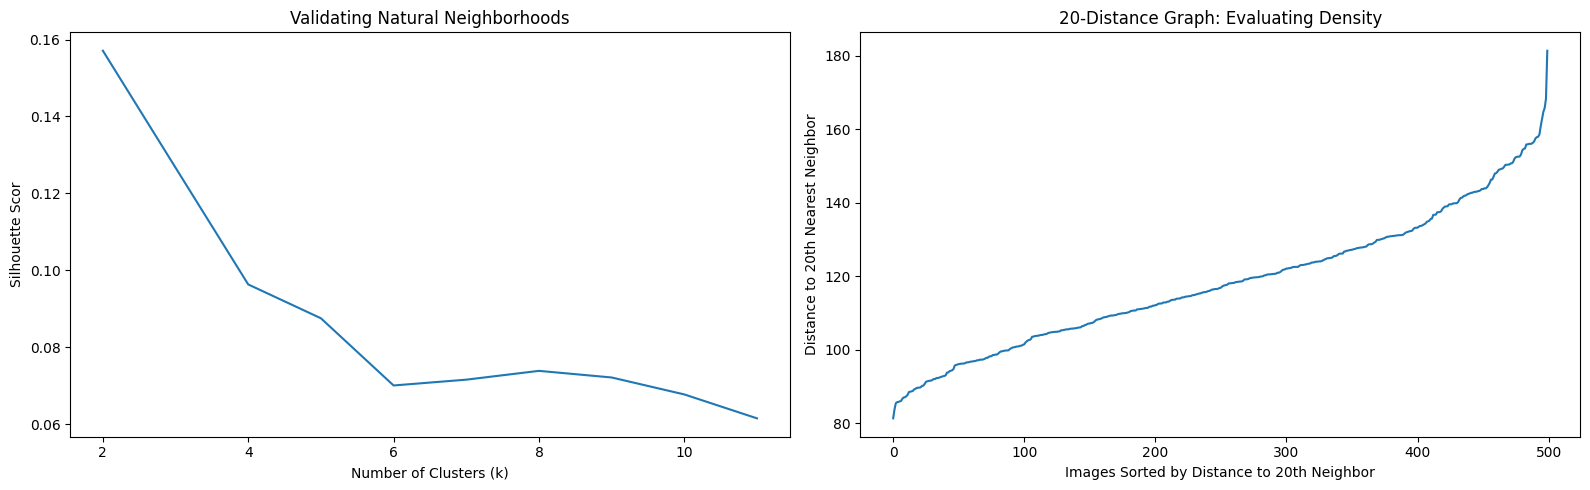

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# K-Means Feasibility
silhouette_scores = []
k_range = range(2, 12)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=67, n_init=10)
    predicted_labels = kmeans.fit_predict(pca_embeddings)

    score = silhouette_score(pca_embeddings, predicted_labels)
    silhouette_scores.append(score)

ax[0].plot(k_range, silhouette_scores)
ax[0].set_title('Validating Natural Neighborhoods')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Silhouette Scor')

# LOF Feasibility
k_neighbors = 20
nn = NearestNeighbors(n_neighbors=k_neighbors)
nn.fit(pca_embeddings)
distances, _ = nn.kneighbors(pca_embeddings)

# Sort the distances to the 20th nearest neighbor
k_distances = np.sort(distances[:, k_neighbors-1])

ax[1].plot(k_distances)
ax[1].set_title(f'{k_neighbors}-Distance Graph: Evaluating Density')
ax[1].set_xlabel('Images Sorted by Distance to 20th Neighbor')
ax[1].set_ylabel(f'Distance to {k_neighbors}th Nearest Neighbor')

plt.tight_layout()
plt.show()

# Tests
assert all(-1 <= score <= 1 for score in silhouette_scores)
assert len(silhouette_scores) == len(k_range)
assert np.all(k_distances >= 0)

The Silhouette analysis reveals that the clustering peaks at k=2 with a very low overall score (0.16). This indicates that the linear PCA space is only capable of finding a single global binary split (likely just separating lighter images from darker images), rather than identifying more complex facial neighborhoods. This proves the need for our change to an autoencoder as linear PCA is too shallow. We require a non-linear deep learning model to successfully untangle the high-dimensional data so that K-Means can find true, distinct sub-populations.

The 20-Distance Graph validates our anomaly detection strategy. The far right tail of the graph shows a severe acceleration, with distances spiking up to 180. This massive mathematical jump proves the existence of low-density statistical outliers relative to the rest of the dataset, justifying the use of Local Outlier Factor (LOF) to isolate them.

**Methodological Planning**
- Course algorithms:

    - K-Means Clustering: Used to partition the latent space into contextual neighborhoods

    - Local Outlier Factor: Used to compute the localized density of each image relative to its specific cluster neighbors and isolates the generative anomalies (deepfakes).

- External algorithms:
    
    - Autoencoder: A neural network trained strictly on the "Real" images to compress the high-dimensional data into a dense, non-linear latent space (This replaces the linear PCA matrix).

- Evaluation:

    - External Evaluation: Since we have the ground-truth labels, the final LOF anomaly scores will be evaluated using ROC-AUC and Precision-Recall AUC. The autoencoder will be evaluated on Mean Squared Error (MSE) of reconstruction.
    
    - Internal Evaluation: Since the metadata is likely to be incomplete with respect to the local neighborhoods, so K-Means will be evaluated on Silhouette Coefficient.

- Baselines:
    - The Global Linear Baseline: To prove the complex pipeline is actually necessary, we will compare its final ROC-AUC against a naive baseline: running a standard global anomaly detector (like Isolation Forest or global LOF) directly on the linear PCA embeddings generated in Checkpoint 1.

-- No additional EDA implementation needed

On my honor, I declare the following resources:
1. Collaborators:
- Gage Mariano: Some code taken from previous checkpoint (loading and PCA).
2. Web Sources:
- https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html: Reference for KMeans
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html: Reference for silhouette score
- https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html: Reference for nearest neighors
3. AI Tools:  
- Gemini:
    - Wrote draft of summary of previous checkpoint.
    - Discussed effective evaluation metrics.
    - Discussed feasibility and effectiveness of pipeline.
    - Verified all answers.